# EDA — Tweets financiers + FiQA-SA

Objectif (RQ2) : mesurer l'effet d'un **changement de domaine dans la même langue** (anglais).
FPB = phrases de dépêches ; ici = tweets et microblogs/titres.

Comme pour FPB, chaque section répond à une question qui mène à une décision
pour `prepare_tweets.py` et `prepare_fiqa.py`.

## 0. Imports et chemins

In [54]:
from collections import Counter
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Le notebook tourne depuis notebooks/ : on remonte à la racine du projet
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
TWEETS_DIR = ROOT / "data" / "raw" / "twitter_financial_news"
FIQA_DIR = ROOT / "data" / "raw" / "fiqa_sa"

LABELS = ["negative", "neutral", "positive"]
# Couleurs par polarité (comme le notebook 01) : rouge = négatif, gris = neutre, bleu = positif
COLORS = {"negative": "#e34948", "neutral": "#8c8b86", "positive": "#2a78d6"}
# Couleurs par jeu de données (identité, ordre fixe)
DATASET_COLORS = {"FPB": "#2a78d6", "Tweets": "#eb6834", "FiQA": "#1baf7a"}

pd.set_option("display.max_colwidth", 200)

# Référence "news" : le train de FPB déjà préparé (jamais le test)
fpb = pd.read_parquet(ROOT / "data" / "processed" / "fpb.parquet")
fpb_train = fpb[fpb["split"] == "train"]
len(fpb_train)

2413

### Deux outils réutilisés dans tout le notebook

- `class_shares` : répartition des classes (en %) de plusieurs jeux ;
- `plot_shares` : la même chose en barres empilées (même graphique que dans le notebook 01).

In [55]:
def class_shares(groups: dict[str, pd.Series]) -> pd.DataFrame:
    """{nom: série de labels} -> tableau effectifs + pourcentages par classe."""
    counts = (pd.DataFrame({name: s.value_counts() for name, s in groups.items()}).T
              .reindex(columns=LABELS).fillna(0).astype(int))
    counts["total"] = counts.sum(axis=1)
    pct = counts[LABELS].div(counts["total"], axis=0).mul(100).round(1).add_suffix(" %")
    return pd.concat([counts, pct], axis=1)


def plot_shares(table: pd.DataFrame, title: str) -> None:
    """Barres horizontales empilées : une barre par jeu, un segment par classe."""
    fig, ax = plt.subplots(figsize=(8, 0.7 * len(table) + 1.5))
    left = pd.Series(0.0, index=table.index)
    for label in LABELS:
        share = table[f"{label} %"]
        ax.barh(table.index, share, left=left, color=COLORS[label], label=label,
                edgecolor="white", linewidth=2)
        for y, (l, s) in enumerate(zip(left, share)):
            if s >= 4:  # pas d'étiquette sur les segments trop fins
                ax.text(l + s / 2, y, f"{s:.0f} %", ha="center", va="center",
                        color="white", fontsize=9)
        left += share
    ax.invert_yaxis()
    ax.set_xlabel("% des exemples")
    ax.set_title(title)
    ax.legend(ncols=3, loc="upper center", bbox_to_anchor=(0.5, -0.3), frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

---
# Partie A — Twitter Financial News

## A1. Charger les fichiers

→ Question : quels splits existent ? (FPB n'en avait aucun, on les a créés nous-mêmes.)

In [56]:
tweets = {s: pd.read_csv(TWEETS_DIR / f"sent_{s}.csv") for s in ["train", "valid"]}
for s, d in tweets.items():
    print(f"{s:5s} : {len(d):5d} lignes, colonnes = {list(d.columns)}")
tweets["train"].head()

train :  9543 lignes, colonnes = ['text', 'label']
valid :  2388 lignes, colonnes = ['text', 'label']


,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0


## A2. Que veulent dire les labels 0, 1, 2 ?

Le README annonce `0 = Bearish, 1 = Bullish, 2 = Neutral`.
Notre schéma est `0 = negative, 1 = neutral, 2 = positive` : **1 et 2 sont inversés**.

On ne croit pas le README sur parole : on **lit** des exemples de chaque chiffre
et on vérifie que le sens correspond.

In [57]:
t = tweets["train"]
for raw_id in sorted(t["label"].unique()):
    print(f"\n===== label brut {raw_id} =====")
    for text in t[t["label"] == raw_id].sample(6, random_state=0)["text"]:
        print("-", text)


===== label brut 0 =====
- VF Corp. shares slide 1.9% premarket
- GBP/JPY Price Forecast – British Pound Fails To Break Out
- Why 51job Shares Dropped 15% Last Month
- Crude Holds Below $50 as OPEC Dithers Over Virus Response
- Exxon Baton Rouge refinery fire threatens oil demand https://t.co/BwrixR2J8d
- Children's Place price target cut to $80 from $105 at Monness Crespi Hardt

===== label brut 1 =====
- Intercontinental Exchange Q4 results in-line, data revenue +4%
- Gold steadies as virus concerns stall stock markets - Nasdaq
- Sanofi Sees Profit Rising in 2020
- Blockbusters like ‘Frozen 2’ will make Disney the first studio to earn $10 billion at the global box office in a si… https://t.co/4e8v3Uo3E4
- $hdge shorts getting killed today

https://t.co/EeN0kh6baB
- Conoco Plans Share Buyback That's Almost 50% of Market Value

===== label brut 2 =====
- WORK, XPO, PYX and AMKR among after hour movers
- Eskom Loses Bid for Higher Tariffs as Court Defers to Regulator
- Edited Transcrip

Si la lecture confirme le README, on traduit **par nom** (Bearish → negative…),
jamais en recopiant les chiffres.
On garde le chiffre d'origine dans `raw_label` pour pouvoir revérifier.

In [58]:
TWEET_LABELS = {0: "negative", 1: "positive", 2: "neutral"}  # Bearish, Bullish, Neutral

tweets = {s: d.rename(columns={"label": "raw_label"})
               .assign(label=lambda x: x["raw_label"].map(TWEET_LABELS))
          for s, d in tweets.items()}
tweets_all = pd.concat([d.assign(split=s) for s, d in tweets.items()], ignore_index=True)
pd.crosstab(tweets_all["raw_label"], tweets_all["label"])  # chaque chiffre -> un seul nom

label,negative,neutral,positive
raw_label,,,
0,1789,0,0
1,0,0,2398
2,0,7744,0


## A3. Répartition des classes, comparée à FPB

→ Décision : stratifier le split, garder la macro-F1, et savoir si le déséquilibre
est différent de celui de FPB (un modèle entraîné sur FPB « a appris » les proportions de FPB).

In [59]:
shares = class_shares({
    "FPB (train)": fpb_train["label"],
    "Tweets train": tweets["train"]["label"],
    "Tweets valid": tweets["valid"]["label"],
})
shares

label,negative,neutral,positive,total,negative %,neutral %,positive %
FPB (train),294,1498,621,2413,12.2,62.1,25.7
Tweets train,1442,6178,1923,9543,15.1,64.7,20.2
Tweets valid,347,1566,475,2388,14.5,65.6,19.9


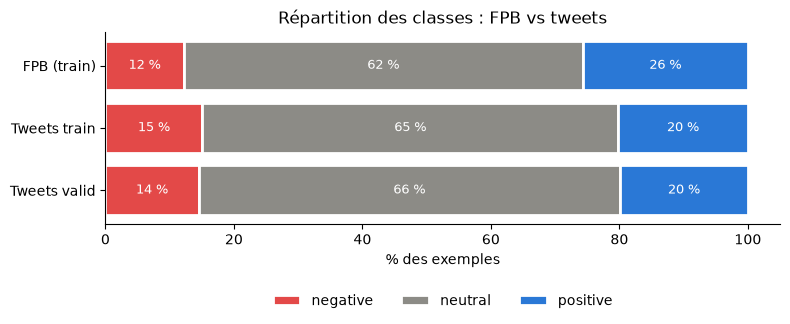

In [60]:
plot_shares(shares, "Répartition des classes : FPB vs tweets")

## A4. Doublons, conflits, fuite entre train et valid

Particularité des tweets : la **même dépêche** est souvent tweetée plusieurs fois avec un
lien raccourci différent (`https://t.co/...`). Deux tweets identiques à l'URL près sont des
doublons « cachés ». On compare donc aussi les textes **sans URL**.

In [61]:
URL = r"https?://\S+"

def without_urls(text: str) -> str:
    return " ".join(re.sub(URL, "", text).split())

rows = []
for s, d in tweets.items():
    for version, texts in [("texte brut", d["text"]), ("sans URL", d["text"].map(without_urls))]:
        df = pd.DataFrame({"text": texts, "label": d["label"]})
        uniq = df.drop_duplicates()
        rows.append({"split": s, "version": version, "lignes": len(df),
                     "doublons exacts": df.duplicated().sum(),
                     "textes en conflit": uniq["text"].duplicated(keep=False).sum()})
pd.DataFrame(rows).set_index(["split", "version"])

lignes  doublons exacts  textes en conflit
split version                                               
train texte brut    9543                0                  0
      sans URL      9543              107                  4
valid texte brut    2388                0                  0
      sans URL      2388               11                  0

In [62]:
# Fuite : un même texte (sans URL) présent en train ET en valid ?
train_texts = set(tweets["train"]["text"].map(without_urls))
valid_texts = set(tweets["valid"]["text"].map(without_urls))
print(f"{len(train_texts & valid_texts)} textes communs à train et valid (sans URL)")

# Tweets qui ne contiennent QU'UNE URL : vides une fois l'URL retirée
empty = tweets_all[tweets_all["text"].map(without_urls) == ""]
print(f"{len(empty)} tweets vides sans leur URL :", empty["label"].value_counts().to_dict())

32 textes communs à train et valid (sans URL)
3 tweets vides sans leur URL : {'neutral': 3}


In [63]:
# Exemples de doublons cachés (identiques une fois l'URL retirée)
d = tweets_all.assign(clean=tweets_all["text"].map(without_urls))
d[d["clean"].duplicated(keep=False)].sort_values("clean")[["text", "label", "split"]].head(10)

,text,label,split
4681,https://t.co/575AH1YRkF,neutral,train
4682,https://t.co/9eZPvQhfMq,neutral,train
4683,https://t.co/oJxNPEUpWq,neutral,train
3907,"""We are only scraping the surface."" The British inventor who built his own 'Iron Man'-style suit has doubled the s… https://t.co/Kq7aD4HUEh",neutral,train
3908,"""We are only scraping the surface."" The British inventor who built his own 'Iron Man'-style suit has doubled the s… https://t.co/yKjuZOueEt",neutral,train
2988,$1 gasoline is back -- and it's a terrible sign for the economy https://t.co/4WRKl5WZ4N,negative,train
2989,$1 gasoline is back -- and it's a terrible sign for the economy https://t.co/5vCkppVHOV,negative,train
757,$AXAS - Abraxas Petroleum: Poor Liquidity Points To A Chapter 11 May Be On The Horizon. https://t.co/bdKkXTKDOL… https://t.co/PG849ZPziP,negative,train
758,$AXAS - Abraxas Petroleum: Poor Liquidity Points To A Chapter 11 May Be On The Horizon. https://t.co/bdKkXTKDOLâ€¦ https://t.co/PG849ZPziP,negative,train
2105,$BONDX: Overnight Treasury Market Summary https://t.co/Klpw9jWgl7,neutral,train


### Décision : option B (comme pour FPB)

Le découpage d'origine a une petite fuite (textes communs à train et valid) et n'a pas de test.
On **fusionne** train + valid, on **nettoie** (clé = texte sans URL), et seulement **ensuite**
on fera notre propre split stratifié 70/15/15 dans `prepare_tweets.py`.
Une phrase ne peut alors plus se retrouver des deux côtés.

Simulation du nettoyage pour voir combien de tweets il reste :

In [64]:
merged = tweets_all.assign(clean=tweets_all["text"].map(without_urls))
not_empty = merged[merged["clean"] != ""]                          # retire les tweets réduits à une URL
no_dup = not_empty.drop_duplicates(subset=["clean", "label"])      # même texte (URL ignorée), même label
conflict = no_dup["clean"].duplicated(keep=False)                  # même texte, labels différents
clean_tweets = no_dup[~conflict]

print(f"fusion train + valid : {len(merged)}")
print(f"  - vides sans URL   : {len(merged) - len(not_empty)}")
print(f"  - doublons         : {len(not_empty) - len(no_dup)}")
print(f"  - en conflit       : {conflict.sum()}")
print(f"= tweets gardés      : {len(clean_tweets)}")
class_shares({"Tweets nettoyés": clean_tweets["label"]})

fusion train + valid : 11931
  - vides sans URL   : 3
  - doublons         : 147
  - en conflit       : 6
= tweets gardés      : 11775


label,negative,neutral,positive,total,negative %,neutral %,positive %
Tweets nettoyés,1765,7630,2380,11775,15.0,64.8,20.2


## A5. Ce qui n'existe pas dans FPB : URL, cashtags, mentions, emojis

→ Décision : que faire de chaque élément dans `prepare_tweets.py`
(le garder, le supprimer, ou le remplacer par un jeton comme `URL`).

In [65]:
PATTERNS = {
    "URL": URL,
    "cashtag ($TSLA)": r"\$[A-Za-z][A-Za-z.]*",
    "mention (@user)": r"@\w+",
    "hashtag (#)": r"#\w+",
    "non ASCII (emoji…)": r"[^\x00-\x7F]",
}
t = tweets["train"]
pd.DataFrame({
    name: {"% tweets": t["text"].str.contains(p).mean() * 100,
           "% phrases FPB": fpb_train["text"].str.contains(p).mean() * 100}
    for name, p in PATTERNS.items()
}).T.round(1)

,% tweets,% phrases FPB
URL,46.8,0.0
cashtag ($TSLA),15.0,0.0
mention (@user),3.1,0.0
hashtag (#),9.4,0.0
non ASCII (emoji…),23.5,2.0


In [66]:
for name, p in PATTERNS.items():
    print(f"\n===== {name} =====")
    for text in t[t["text"].str.contains(p)].sample(3, random_state=0)["text"]:
        print("-", text)


===== URL =====
- Grifols : December 6, 2019 Grifols presents its latest Alzheimer's clinical trial data #Grifols #Stock… https://t.co/Dnt4oYb4SP
- How are technological advances causing a boom in renewable energy? Find out in our new infographic, "The Power Shif… https://t.co/gVDgEE6ArY
- Report: 43% of investors interested in bitcoin are women https://t.co/RrvQys6ZVd by @readDanwrite https://t.co/q96etM9iQQ

===== cashtag ($TSLA) =====
- $COMDX: Metals Settlement Prices https://t.co/AS20EVgY5E
- $GT - Goodyear Tire & Rubber Q4 2019 Earnings Preview https://t.co/435GSK0ybQ
- $PSCF - Invesco S&P SmallCap Financials ETF declares $0.47 dividend https://t.co/YverZnfDT0

===== mention (@user) =====
- Why the Disney+ 'hack' shows data is like 'oil' that needs to be secured
https://t.co/UdUMRuYRQp by @GreteSuarez https://t.co/M9jaT6TpcB
- What's the best novel you've read this year? Our favourite authors of 2019 include: @MargaretAtwood @taffyakner… https://t.co/DklppqCBmY
- OPEC+ Output Cu

Question piège : la **présence d'une URL** est-elle liée au label ?
Si oui, un modèle pourrait apprendre « URL → neutral » au lieu du sens de la phrase :
c'est un raccourci qui ne marchera pas sur d'autres données.

In [67]:
has_url = t["text"].str.contains(URL).map({True: "avec URL", False: "sans URL"})
pd.crosstab(has_url, t["label"], normalize="index").mul(100).round(1)[LABELS]

label,negative,neutral,positive
text,,,
avec URL,14.3,68.9,16.8
sans URL,15.8,61.1,23.1


---
# Partie B — FiQA-SA

## B1. Charger les fichiers

FiQA vient d'une tâche **par aspect** : une phrase, une *cible* (entreprise), un *aspect*,
et un **score continu** de −1 à +1 (pas 3 classes).

In [68]:
fiqa = {s: pd.read_parquet(FIQA_DIR / f"{s}.parquet") for s in ["train", "valid", "test"]}
fiqa_all = pd.concat([d.assign(split=s) for s, d in fiqa.items()], ignore_index=True)
for s, d in fiqa.items():
    print(f"{s:5s} : {len(d):4d} lignes")
fiqa_all.head()

train :  822 lignes
valid :  117 lignes
test  :  234 lignes


,_id,sentence,target,aspect,score,type,split
0,1,Royal Mail chairman Donald Brydon set to step down,Royal Mail,Corporate/Appointment,-0.374,headline,train
1,100,Slump in Weir leads FTSE down from record high,Weir,Market/Volatility/Volatility,-0.827,headline,train
2,1000,AstraZeneca wins FDA approval for key new lung cancer pill,AstraZeneca,Corporate/Regulatory,0.549,headline,train
3,1002,UPDATE 1-Lloyds to cut 945 jobs as part of 3-year restructuring plan,Lloyds,Corporate/Strategy,-0.266,headline,train
4,1005,Standard Chartered Shifts Emerging-Markets Strategy After Losses,Standard Chartered,Corporate/Strategy,-0.461,headline,train


In [69]:
# Deux types de textes : titres de presse (headline) et microblogs (post)
fiqa_all.groupby(["split", "type"]).size().unstack()

type,headline,post
split,,
test,99,135
train,349,473
valid,50,67


## B2. Distribution du score

→ Question : le score est-il concentré autour de 0 (beaucoup de « neutre »)
ou plutôt tranché ?

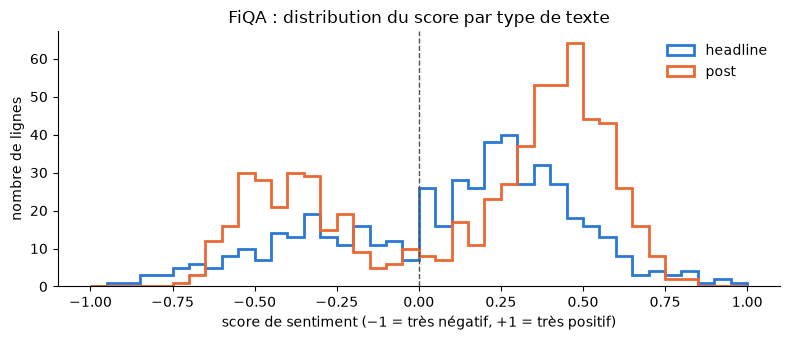

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
headline,498.0,0.093,0.376,-0.938,-0.185,0.189,0.365,0.975
post,675.0,0.143,0.414,-0.745,-0.301,0.318,0.476,0.814


In [70]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(-1, 1, 41)
for typ, color in [("headline", "#2a78d6"), ("post", "#eb6834")]:
    ax.hist(fiqa_all.loc[fiqa_all["type"] == typ, "score"], bins=bins, histtype="step",
            linewidth=2, color=color, label=typ)
ax.axvline(0, color="#52514e", linestyle="--", linewidth=1)
ax.set_xlabel("score de sentiment (−1 = très négatif, +1 = très positif)")
ax.set_ylabel("nombre de lignes")
ax.set_title("FiQA : distribution du score par type de texte")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

fiqa_all.groupby("type")["score"].describe().round(3)

## B3. Passer du score à 3 classes : quel seuil ?

Règle : `score < −s` → negative, `score > s` → positive, sinon neutral.
Le choix de `s` change complètement la taille de la classe « neutral ».

→ Décision : un seuil **justifié** (et identique pour train/valid/test).

In [71]:
def discretize(scores: pd.Series, s: float) -> pd.Series:
    return pd.Series(np.select([scores < -s, scores > s], ["negative", "positive"], "neutral"),
                     index=scores.index)

THRESHOLDS = [0.0, 0.05, 0.1, 0.2, 0.3]
by_threshold = class_shares({f"seuil ±{s}": discretize(fiqa_all["score"], s) for s in THRESHOLDS})
by_threshold

,negative,neutral,positive,total,negative %,neutral %,positive %
seuil ±0.0,399,14,760,1173,34.0,1.2,64.8
seuil ±0.05,382,51,740,1173,32.6,4.3,63.1
seuil ±0.1,363,93,717,1173,30.9,7.9,61.1
seuil ±0.2,321,217,635,1173,27.4,18.5,54.1
seuil ±0.3,264,402,507,1173,22.5,34.3,43.2


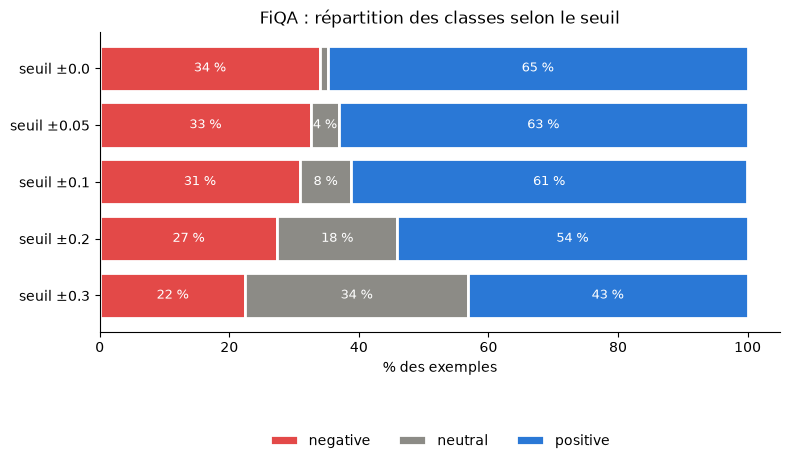

In [72]:
plot_shares(by_threshold, "FiQA : répartition des classes selon le seuil")

Lire les phrases **proches de la frontière** : à partir de quel score une phrase
cesse-t-elle d'être neutre pour un investisseur ? (consigne FPB)

In [73]:
near = fiqa_all[fiqa_all["score"].abs() <= 0.25].sort_values("score")
near[["score", "sentence"]].iloc[::max(1, len(near) // 20)]  # ~20 phrases réparties

,score,sentence
1158,-0.248,$AAPL Beat the estimates. Will still go down on lack of new products. https://t.co/sX3z7u6N8o
882,-0.227,$TSLA recall
281,-0.198,"FDA panel backs safety updates for AstraZeneca, Takeda drugs"
652,-0.169,@saltwaternurse $INO can test 10 again in next few days. time to take some profits here. or hedge with puts.
195,-0.140,"Goldman Sachs, Barclays, HSBC downplay Brexit threat"
415,-0.088,My $DWA play up 6% today. I'm still skeptical. Will take profits. Not a time cheer
286,-0.046,Germanwings disaster will not affect image of budget air travel - easyJet
638,-0.009,$AMZN Trailing 12 months operating cash flow rose 48% to $4.98 billion & free cash flow decreased 63% to $388 million http://stks.co/c06zG
855,0.002,RSA Insurance Hires Towergate's Egan as Chief Financial Officer
633,0.041,$PRGN A bottom right here?


## B4. Une phrase, plusieurs cibles

Comme FiQA note le sentiment **envers une cible**, une même phrase peut apparaître
plusieurs fois avec des scores différents.
Pour nous (une phrase → un label), ce sont des doublons ou des conflits.

In [74]:
multi = fiqa_all[fiqa_all["sentence"].duplicated(keep=False)].sort_values("sentence")
print(f"{multi['sentence'].nunique()} phrases apparaissent plusieurs fois ({len(multi)} lignes)")
multi[["sentence", "target", "aspect", "score", "split"]].head(12)

57 phrases apparaissent plusieurs fois (119 lignes)


,sentence,target,aspect,score,split
986,ARM Holdings plc Partners With International Business Machines Corp. To Drive ...,ARM Holdings,Corporate/Strategy,0.273,test
987,ARM Holdings plc Partners With International Business Machines Corp. To Drive ...,IBM,Corporate/Strategy,0.345,test
989,"After Barclays and Bank of America, Citigroup has blockchain in sight",Barclays,Corporate/Strategy/Investment,0.198,test
990,"After Barclays and Bank of America, Citigroup has blockchain in sight",Citigroup,Corporate/Strategy/Investment,0.224,test
205,"Are ARM Holdings plc, Domino's Pizza Group plc and ASOS plc 3 must-have growth stocks?",Domino's Pizza Group plc,Corporate/Rumors/Scoop,0.063,train
206,"Are ARM Holdings plc, Domino's Pizza Group plc and ASOS plc 3 must-have growth stocks?",ASOS plc,Corporate/Rumors/Scoop,0.000,train
25,"Are Aviva plc, Direct Line Insurance Group PLC And Admiral Group plc Set To Soar?",Aviva,Corporate/Company Communication,0.324,train
26,"Are Aviva plc, Direct Line Insurance Group PLC And Admiral Group plc Set To Soar?",Direct Line Insurance Group PLC,Corporate/Company Communication,0.345,train
198,Asahi could be about to snap up more of SABMiller's beers ahead of AB InBev sale,Asahi,Corporate/Strategy/Investment,0.207,train
199,Asahi could be about to snap up more of SABMiller's beers ahead of AB InBev sale,SABMiller,Corporate/Strategy/Investment,0.329,train


In [75]:
# Après discrétisation (ex. seuil 0.1) : combien de ces phrases ont des labels différents ?
# Et une même phrase est-elle répartie sur plusieurs splits (fuite) ?
g = fiqa_all.assign(label=discretize(fiqa_all["score"], 0.1)).groupby("sentence")
print("phrases en conflit de label    :", (g["label"].nunique() > 1).sum())
print("phrases sur plusieurs splits   :", (g["split"].nunique() > 1).sum())

phrases en conflit de label    : 12
phrases sur plusieurs splits   : 0


## B5. Les mêmes éléments « réseaux sociaux » que dans les tweets ?

Les `post` sont des microblogs (StockTwits) : on réutilise les motifs de A5.

In [76]:
pd.DataFrame({
    name: fiqa_all.groupby("type")["sentence"].apply(lambda s: s.str.contains(p).mean() * 100)
    for name, p in PATTERNS.items()
}).round(1)

,URL,cashtag ($TSLA),mention (@user),hashtag (#),non ASCII (emoji…)
type,,,,,
headline,0.0,0.0,0.0,0.0,3.2
post,37.2,100.0,11.0,6.4,0.6


---
# Partie C — Les trois domaines côte à côte

## C1. Longueur des textes (en mots)

→ Décision (étape 5) : `max_length` des Transformers pour les trois jeux.

In [77]:
texts = {
    "FPB": fpb_train["text"],
    "Tweets": tweets["train"]["text"].map(without_urls),
    "FiQA": fiqa_all["sentence"].map(without_urls),
}
lengths = pd.DataFrame({name: s.str.split().str.len().describe(percentiles=[0.5, 0.95, 0.99])
                        for name, s in texts.items()}).T.round(1)
lengths

,count,mean,std,min,50%,95%,99%,max
FPB,2413.0,22.9,10.2,2.0,21.0,43.0,50.0,81.0
Tweets,9543.0,11.6,4.4,0.0,11.0,20.0,22.0,31.0
FiQA,1173.0,11.6,5.1,2.0,10.0,23.0,25.0,30.0


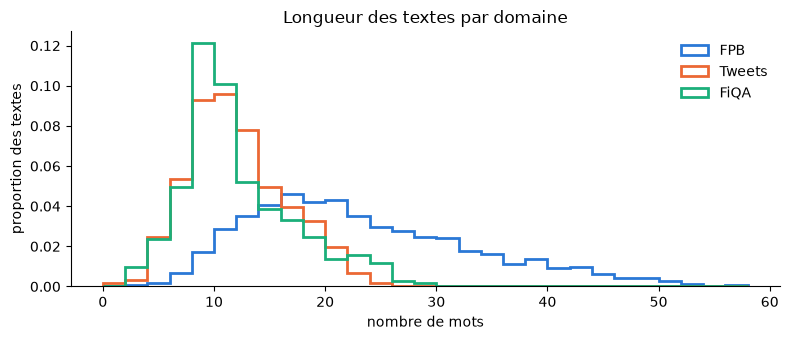

In [78]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bins = range(0, 60, 2)
for name, s in texts.items():
    n_words = s.str.split().str.len()
    ax.hist(n_words, bins=bins, histtype="step", linewidth=2, density=True,
            color=DATASET_COLORS[name], label=name)
ax.set_xlabel("nombre de mots")
ax.set_ylabel("proportion des textes")
ax.set_title("Longueur des textes par domaine")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## C2. Vocabulaire : à quel point les tweets et FiQA sont-ils « nouveaux » pour un modèle FPB ?

Taux de mots **hors vocabulaire** : la part des mots d'un jeu jamais vus dans le train de FPB.
C'est une mesure directe du changement de domaine pour la baseline TF-IDF :
un mot jamais vu à l'entraînement n'a aucun poids dans le modèle.

In [79]:
def words(text: str) -> list[str]:
    return re.findall(r"[a-z]+", text.lower())

fpb_vocab = {w for text in fpb_train["text"] for w in words(text)}

rows = {}
for name, s in texts.items():
    tokens = [w for text in s for w in words(text)]
    unseen = [w for w in tokens if w not in fpb_vocab]
    rows[name] = {"mots (occurrences)": len(tokens),
                  "% hors vocabulaire FPB": round(len(unseen) / len(tokens) * 100, 1),
                  "mots inconnus les plus fréquents": ", ".join(
                      w for w, _ in Counter(unseen).most_common(12))}
pd.DataFrame(rows).T

,mots (occurrences),% hors vocabulaire FPB,mots inconnus les plus fréquents
FPB,46526,0.0,
Tweets,109616,28.3,"marketscreener, beats, fed, coronavirus, hedge, declares, trump, transcript, misses, announces, dow, premarket"
FiQA,13336,31.0,"aapl, tsla, fb, tesco, spy, astrazeneca, sabmiller, breakout, resistance, chart, inbev, nice"


## C3. Répartition des classes des trois jeux

(FiQA avec un seuil provisoire de 0.1, à confirmer en conclusion.)

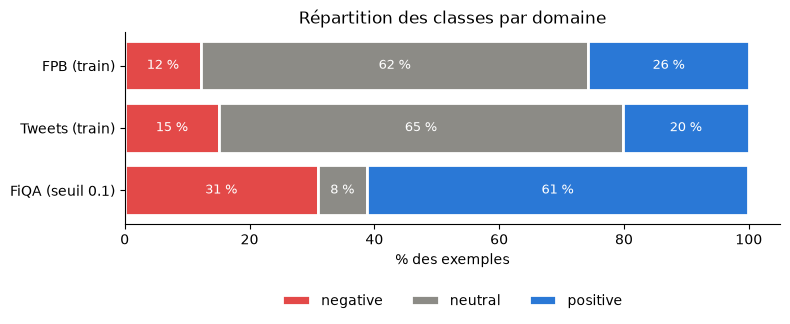

In [80]:
plot_shares(class_shares({
    "FPB (train)": fpb_train["label"],
    "Tweets (train)": tweets["train"]["label"],
    "FiQA (seuil 0.1)": discretize(fiqa_all["score"], 0.1),
}), "Répartition des classes par domaine")

---
## D. Conclusions → décisions pour `prepare_tweets.py` et `prepare_fiqa.py`

À remplir ensemble après avoir lu les résultats :

**Tweets**
- Correspondance des labels : 0 = Bearish → negative, 1 = Bullish → positive, 2 = Neutral → neutral,
  traduite **par nom** (vérifiée en lisant les exemples, A2).
- Split : **option B**. Fusion train + valid → nettoyage → split stratifié 70/15/15, seed 42 (comme FPB).
  Raisons : fuite de 32 textes entre train et valid dans le découpage d'origine, et pas de test.
- Doublons cachés : dédoublonnage et conflits calculés sur le **texte sans URL**, **avant** le split ;
  les tweets réduits à une URL sont retirés.
- URL / cashtags / mentions : …
- Caractères mal encodés (`â€¦` au lieu de `…`) : …

**FiQA**
- Seuil de discrétisation : …
- Phrases à plusieurs cibles : …
- Splits (garder ceux d'origine ?) : …

**Comparaison**
- Changement de domaine attendu (hors vocabulaire, longueur, classes) : …
- `max_length` envisagé : …